## Distance to land

This notebook opens gridded distance to land dataset downloaded from https://pae-paha.pacioos.hawaii.edu/thredds/ncss/dist2coast_1deg_ocean/dataset.html .

In [1]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

In [2]:
folder_name = "inputs\dist2coast_1deg_ocean.nc"
ds = nc.Dataset(folder_name)
ds.variables.keys()

dict_keys(['dist', 'lat', 'lon'])

In [3]:
lat_grid  = ds.variables['lat'][:]   # -90 to 90
lon_grid  = ds.variables['lon'][:]   # -180 to 180
dist = ds.variables['dist'][:]  # distance in km

ds.close()

print(f"Distance range: {np.nanmin(dist):.2f} to {np.nanmax(dist):.2f} km")

Distance range: 1.00 to 2695.00 km


In [4]:
def get_dist2coast(lat_query, lon_query, output_storage, lat, lon, dist):
    """
    Returns distance to nearest coastline in km for an ocean point.
    Uncertainty: ~1 km at any given point.
    """
    lat_idx = np.argmin(np.abs(lat - lat_query))
    lon_idx = np.argmin(np.abs(lon - lon_query))

    val = dist[lat_idx, lon_idx]

    if np.ma.is_masked(val) or np.isnan(float(val)):
        print(f"({lat_query}, {lon_query}) → no ocean data (land point?)")
        output_storage.append("land")
        return None

    val = float(val)
    print(f"Query        : {lat_query}°N, {lon_query}°E")
    print(f"Nearest cell : {float(lat[lat_idx]):.4f}°N, {float(lon[lon_idx]):.4f}°E")
    print(f"Dist2coast   : {val:.2f} km")

    output_storage.append(val*1000)  # convert to meters

    return val

In [6]:
data_points = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1
...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1


In [7]:
lat = data_points['Lat_center'].to_list()
lon = data_points['Lon_center'].to_list()

In [8]:
out=[]
for i in range(len(lat)):
    get_dist2coast(lat[i], lon[i], out, lat_grid, lon_grid, dist)

(-74.5, 163.5) → no ocean data (land point?)
(-74.5, 164.5) → no ocean data (land point?)
(-42.5, 147.5) → no ocean data (land point?)
Query        : -38.5°N, 144.5°E
Nearest cell : -38.5000°N, 144.5000°E
Dist2coast   : 23.00 km
(-35.5, 138.5) → no ocean data (land point?)
(-34.5, 150.5) → no ocean data (land point?)
Query        : -23.5°N, -43.5°E
Nearest cell : -23.5000°N, -43.5000°E
Dist2coast   : 48.00 km
(-22.5, -43.5) → no ocean data (land point?)
Query        : -6.5°N, 112.5°E
Nearest cell : -6.5000°N, 112.5000°E
Dist2coast   : 38.00 km
Query        : -5.5°N, 106.5°E
Nearest cell : -5.5000°N, 106.5000°E
Dist2coast   : 4.00 km
(1.5, 103.5) → no ocean data (land point?)
Query        : 6.5°N, 93.5°E
Nearest cell : 6.5000°N, 93.5000°E
Dist2coast   : 46.00 km
Query        : 7.5°N, 77.5°E
Nearest cell : 7.5000°N, 77.5000°E
Dist2coast   : 64.00 km
Query        : 7.5°N, 93.5°E
Nearest cell : 7.5000°N, 93.5000°E
Dist2coast   : 4.00 km
Query        : 7.5°N, 94.5°E
Nearest cell : 7.5000°N,

In [9]:
out
output = pd.DataFrame(out, columns=['distance'])

data_points['Distance to land'] = output['distance']
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Distance to land
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,land
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,land
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,land
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,23000.0
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,land
...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,312000.0
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,335000.0
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,352000.0
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,434000.0


In [10]:
# Replace 'land' points by 0 
data_points["Distance to land"] = data_points["Distance to land"].replace("land", 0.0).astype(float)

In [11]:
data_points.to_csv('outputs\Distance to land dataset.csv', index=False)

## Statistics

In [12]:
# Normalize data for statistics
data_points_copy = data_points.copy()
data_points_copy['Distance to land'] = data_points_copy['Distance to land'].apply(pd.to_numeric, errors='coerce').fillna(0)

cols_to_normalize = ['MEAN MP stock (g/m2) in 2021',
                     'Distance to land']

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]


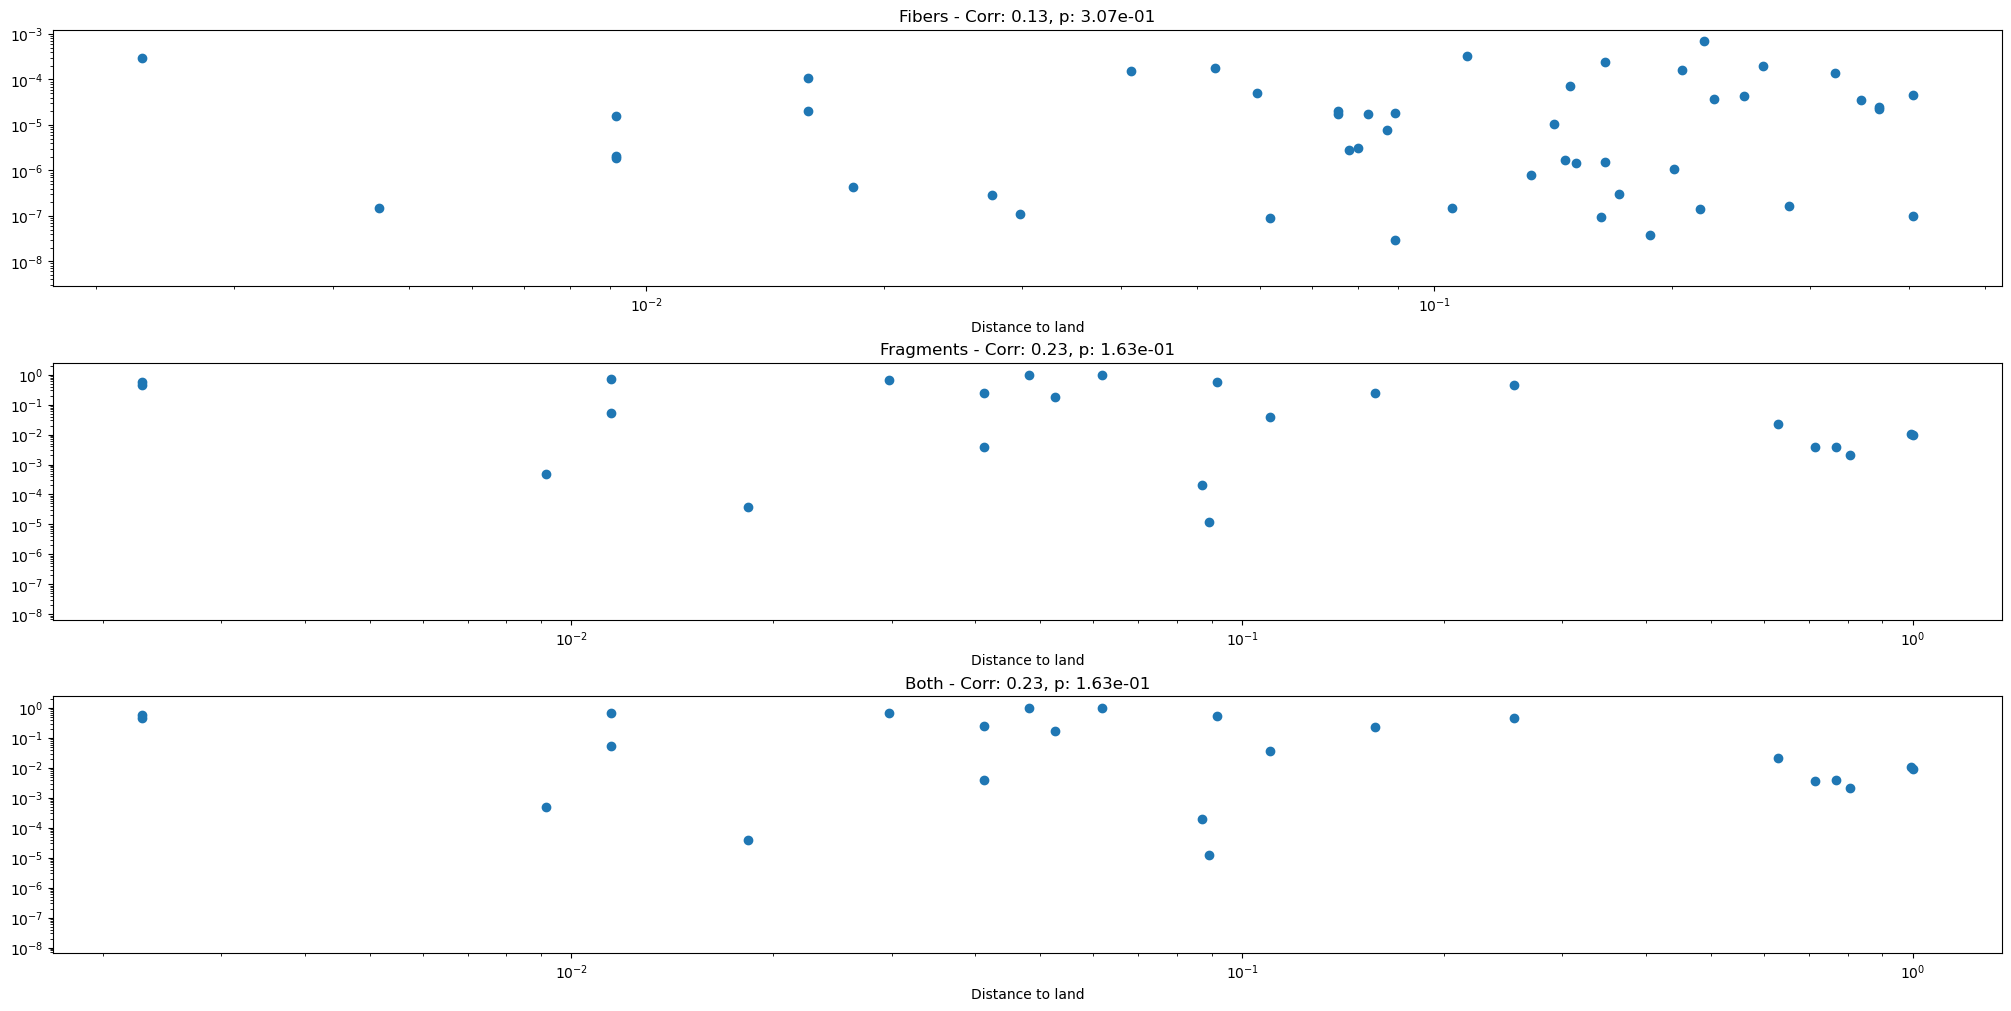

In [13]:
fig, axs = plt.subplots(3, 1, layout="constrained", figsize=(20, 10))
ax1, ax2, ax3 = axs.flatten()

cmap = plt.colormaps['plasma']

spearman_results = []

# Fibers
x = data_points_fib['Distance to land']
y = data_points_fib['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Distance to land Fibers stock', spearman_stock[0], spearman_stock[1]])

ax1.scatter(data_points_fib['Distance to land'], data_points_fib['MEAN MP stock (g/m2) in 2021'])
ax1.set_title(f"Fibers - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Fragments
x = data_points_frg['Distance to land']
y = data_points_frg['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Distance to land Fragments stock', spearman_stock[0], spearman_stock[1]])

ax2.scatter(data_points_frg['Distance to land'], data_points_frg['MEAN MP stock (g/m2) in 2021'])
ax2.set_title(f"Fragments - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Both
x = data_points_frg['Distance to land']
y = data_points_frg['MEAN MP stock (g/m2) in 2021']

mask = np.isfinite(x) & np.isfinite(y)
spearman_stock = stats.spearmanr(x[mask], y[mask])

spearman_results.append(['Distance to land Both together stock', spearman_stock[0], spearman_stock[1]])

ax3.scatter(data_points_frg['Distance to land'], data_points_frg['MEAN MP stock (g/m2) in 2021'])
ax3.set_title(f"Both - Corr: {spearman_stock[0]:.2f}, p: {spearman_stock[1]:.2e}")

# Labels

for ax in axs.flatten():
    ax.set_xlabel('Distance to land')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.show()

In [14]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats

,Parameter,Spearman Correlation,Spearman p-value
0,Distance to land Fibers stock,0.128592,0.307317
1,Distance to land Fragments stock,0.228050,0.162619
2,Distance to land Both together stock,0.228050,0.162619
